# Laboratorio 5

- Mathew Alexander Cordero Aquino - 22982
- Gustavo Adolfo Cruz Bardales - 22779
- Edwin de Leon - 22809

[Repositorio](https://github.com/donmatthiuz/VIC/tree/lab5)

## Task 1

### Imagenes de Control

#### Izquierda

![image.png](attachment:image.png)

#### Derecha

![image-2.png](attachment:image-2.png)

### Imagenes Experimentales

#### Objetos:
- Cercano: Botella transparente
- Medio: Sofa
- Lejano: Porton

#### Izquierda

![image.png](attachment:image.png)

#### Derecha

![image-2.png](attachment:image-2.png)


## Task 2


In [ ]:

import cv2
import numpy as np

def pipelineSTICKING(img_left_path, img_right_path, name_output):
    img_left  = cv2.imread(img_left_path)
    img_right = cv2.imread(img_right_path)

    if img_left is None or img_right is None:
        raise ValueError("Error cargando imágenes")

    gray_left  = cv2.cvtColor(img_left,  cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(gray_left,  None)
    kp2, des2 = sift.detectAndCompute(gray_right, None)

    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)

    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    if len(good) < 8:
        raise ValueError("Muy pocos matches para estimar homografía")

    pts_left  = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    pts_right = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    H, inliers = cv2.findHomography(
        pts_right,
        pts_left,
        cv2.RANSAC,
        5.0
    )

    if H is None:
        raise ValueError("No se pudo estimar la homografía")

    h, w = img_left.shape[:2]

    corners_right = np.array([[0,0],[w,0],[w,h],[0,h]], dtype=np.float32).reshape(-1,1,2)
    warped_corners = cv2.perspectiveTransform(corners_right, H)

    corners_left = np.array([[0,0],[w,0],[w,h],[0,h]], dtype=np.float32).reshape(-1,1,2)

    all_corners = np.concatenate((corners_left, warped_corners), axis=0)

    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 10)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 10)

    panorama_w = x_max - x_min
    panorama_h = y_max - y_min

    T = np.array([
        [1, 0, -x_min],
        [0, 1, -y_min],
        [0, 0, 1]
    ], dtype=np.float32)

    warped = cv2.warpPerspective(img_right, T @ H, (panorama_w, panorama_h))

    panorama = np.zeros((panorama_h, panorama_w, 3), dtype=np.uint8)

    panorama[-y_min:h-y_min, -x_min:w-x_min] = img_left

    mask = warped > 0
    panorama[mask] = warped[mask]

    cv2.imwrite(f"{name_output}.png", panorama)



### Stiching

In [ ]:

pipelineSTICKING("control\lefth.jpeg", "control\\right.jpeg" ,"panorama_control")
pipelineSTICKING("experimental\lefth.jpeg", "experimental\\right.jpeg" ,"panorama_experimental")


<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\l'
C:\Users\donMatthiuz\AppData\Local\Temp\ipykernel_19364\2478358849.py:1: SyntaxWarning: invalid escape sequence '\l'
  pipelineSTICKING("control\lefth.jpeg", "control\\right.jpeg" ,"panorama_control")
C:\Users\donMatthiuz\AppData\Local\Temp\ipykernel_19364\2478358849.py:2: SyntaxWarning: invalid escape sequence '\l'
  pipelineSTICKING("experimental\lefth.jpeg", "experimental\\right.jpeg" ,"panorama_experimental")


### Detectar Errores

In [ ]:
def pipeline_detect_errors(img_left_path, img_right_path, name_output):
    print("[1/7] Cargando imágenes...")

    base = cv2.imread(img_left_path)
    warped = cv2.imread(img_right_path)

    if base is None or warped is None:
        raise ValueError("❌ Error cargando las imágenes")

    cv2.imshow("Base", base)
    cv2.imshow("Warped", warped)
    cv2.waitKey(500)

    print("[2/7] Redimensionando...")
    h, w = base.shape[:2]
    warped = cv2.resize(warped, (w, h))

    print("[3/7] Convirtiendo a escala de grises...")
    base_gray = cv2.cvtColor(base, cv2.COLOR_BGR2GRAY)
    warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

    cv2.imshow("Base Gray", base_gray)
    cv2.imshow("Warped Gray", warped_gray)
    cv2.waitKey(500)

    print("[4/7] Creando anaglifo...")
    anaglyph = np.zeros((h, w, 3), dtype=np.uint8)

    print("[5/7] Asignando canal rojo (base)...")
    anaglyph[:, :, 2] = base_gray   # R

    print("[6/7] Asignando canal cian (warped)...")
    anaglyph[:, :, 1] = warped_gray  # G
    anaglyph[:, :, 0] = warped_gray  # B

    print("[7/7] Mostrando resultado final...")

    cv2.imshow("Anaglifo Rojo-Cian (Blending Visual)", anaglyph)
    cv2.imwrite(f"{name_output}.png", anaglyph)

    print("✅ Proceso terminado. Imagen guardada como anaglyph_result.png")

    cv2.destroyAllWindows()


In [ ]:
pipeline_detect_errors("control\lefth.jpeg", "control\\right.jpeg" ,"test_control")
pipeline_detect_errors("experimental\lefth.jpeg", "experimental\\right.jpeg" ,"test_experimental")



<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\l'
C:\Users\donMatthiuz\AppData\Local\Temp\ipykernel_19364\3358978910.py:1: SyntaxWarning: invalid escape sequence '\l'
  pipeline_detect_errors("control\lefth.jpeg", "control\\right.jpeg" ,"test_control")
C:\Users\donMatthiuz\AppData\Local\Temp\ipykernel_19364\3358978910.py:2: SyntaxWarning: invalid escape sequence '\l'
  pipeline_detect_errors("experimental\lefth.jpeg", "experimental\\right.jpeg" ,"test_experimental")


[1/7] Cargando imágenes...
[2/7] Redimensionando...
[3/7] Convirtiendo a escala de grises...
[4/7] Creando anaglifo...
[5/7] Asignando canal rojo (base)...
[6/7] Asignando canal cian (warped)...
[7/7] Mostrando resultado final...
✅ Proceso terminado. Imagen guardada como anaglyph_result.png
[1/7] Cargando imágenes...
[2/7] Redimensionando...
[3/7] Convirtiendo a escala de grises...
[4/7] Creando anaglifo...
[5/7] Asignando canal rojo (base)...
[6/7] Asignando canal cian (warped)...
[7/7] Mostrando resultado final...
✅ Proceso terminado. Imagen guardada como anaglyph_result.png


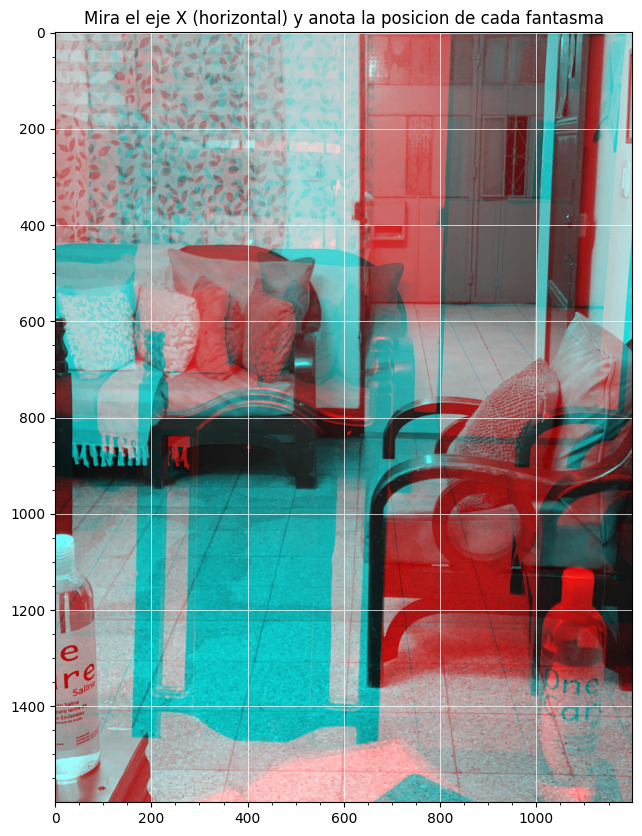

,Objeto,Distancia Real,Coord X Rojo,Coord X Cian,Disparidad (px)
0,A (Cercano),50 cm,585,835,250
1,B (Medio),1.5 m,292,501,209
2,C (Fondo),> 3 m,41,209,168


In [ ]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd

img = cv2.imread('test_experimental.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.grid(True, color='white', linestyle='-', linewidth=0.5)
plt.minorticks_on()
plt.title("Mira el eje X (horizontal) y anota la posicion de cada fantasma")
plt.show()

# Cercano
x_A_rojo = 585
x_A_cian = 835

# Medio
x_B_rojo = 292
x_B_cian = 501

# Fondo
x_C_rojo = 41
x_C_cian = 209

data = {
    "Objeto": ["A (Cercano)", "B (Medio)", "C (Fondo)"],
    "Distancia Real": ["50 cm", "1.5 m", "> 3 m"],
    "Coord X Rojo": [x_A_rojo, x_B_rojo, x_C_rojo],
    "Coord X Cian": [x_A_cian, x_B_cian, x_C_cian]
}

df = pd.DataFrame(data)
df["Disparidad (px)"] = abs(df["Coord X Rojo"] - df["Coord X Cian"])

display(df)

#  Task 3 — Análisis Experimental de Disparidad

##  Datos (Set experimental)

- **A (Cercano, ~0.50 m):**  
  \( x_{rojo} = 585 \), \( x_{cian} = 835 \)  
  - \( d = |585 - 835| = 250 \) px

- **B (Medio, ~1.5 m):**  
  \( x_{rojo} = 292 \), \( x_{cian} = 501 \)  
  - \( d = |292 - 501| = 209 \) px

- **C (Fondo, >3 m):**  
  \( x_{rojo} = 41 \), \( x_{cian} = 209 \)  
  - \( d = |41 - 209| = 168 \) px



## 1️) Tendencia de la disparidad

Sí existe una tendencia clara, en los datos observados, la **disparidad disminuye conforme aumenta la distancia real del objeto**.

- **A (0.50 m)** - 250 px  
- **B (1.5 m)** - 209 px  
- **C (>3 m)** - 168 px  

###  Conclusión

A mayor profundidad (objeto más lejano), **menor es la separación de los “fantasmas” en píxeles**, el objeto cercano (botella) es el que más se duplica, mientras que el objeto del fondo (portón) es el que menos desplazamiento presenta.



## 2️) ¿Relación lineal \( d = kZ \) o inversa \( d = \frac{k}{Z} \)?

Con base en los tres puntos experimentales, el comportamiento observado es **decreciente** (cuando \( Z \) aumenta, \( d \) disminuye).

Por lo tanto:

-  **No se parece a una relación lineal** \( d = k \cdot Z \)  
  (esto implicaría que la disparidad aumenta con la distancia).

-  **Se parece más a una relación inversa**:

\[
d \approx \frac{k}{Z}
\]

###  Evidencia en los datos

Al pasar de:

- **0.5 m - 1.5 m - 3 m**

la disparidad baja de:

- **250 - 209 - 168 px**

Esto coincide con el comportamiento esperado en estereoscopía.

>  **Nota:** La relación no es perfectamente inversa porque las distancias son aproximadas y el fondo está definido como “>3 m”, sin embargo, la tendencia experimental coincide mucho más con \( 1/Z \) que con una relación lineal creciente.



##  Mini-gráfica conceptual

Si se grafica la profundidad \( Z \) en el eje X y la disparidad \( d \) en el eje Y, los puntos experimentales son:

- (0.5, 250)  
- (1.5, 209)  
- (>3, 168)  

La distribución muestra una **curva decreciente**, consistente con una relación inversa entre profundidad y disparidad.



## 3️) ¿Por qué falló la homografía y qué información 3D estaba escondida?

El algoritmo de panoramas basado en homografía funciona correctamente cuando se cumple al menos una de estas suposiciones:

-  La cámara realiza **rotación pura** (sin traslación).  
-  La escena es **aproximadamente plana** (un solo plano dominante).

En el set experimental se realizó una **traslación lateral** de aproximadamente 15–30 cm. Esto introduce **paralaje**, el cual depende directamente de la profundidad de los objetos.

###  Efecto observado

- **Objetos cercanos (botella)**  
  - gran cambio de posición aparente  
  - **gran disparidad (250 px)**

- **Objetos medios (sofá)**  
  - cambio moderado  
  - **disparidad intermedia (209 px)**

- **Objetos lejanos (portón)**  
  - cambio pequeño  
  - **disparidad menor (168 px)**



###  Por qué la homografía no pudo alinear todo

No existe una única homografía capaz de alinear simultáneamente puntos que pertenecen a **distintas profundidades** en una escena 3D.

Por ello, RANSAC:

- selecciona el **plano dominante** (normalmente el fondo),
- alinea correctamente ese plano,
- pero deja desalineados los objetos cercanos,

lo que produce los **“fantasmas”** observados en la imagen compuesta.



##  Información 3D escondida en el fallo

El fallo del algoritmo revela información tridimensional de la escena, la disparidad medida contiene la señal fundamental de la estereoscopía:

\[
\text{más cerca} \Rightarrow \text{mayor disparidad}
\]
\[
\text{más lejos} \Rightarrow \text{menor disparidad}
\]

###  Conclusión general

El experimento demuestra que la homografía funciona correctamente solo bajo rotación pura, al introducir traslación aparece paralaje dependiente de la profundidad, la medición de la disparidad confirma empíricamente una relación inversa entre profundidad y desplazamiento en píxeles, evidenciando la estructura tridimensional de la escena.